In [ ]:
!pip install torch torchvision segmentation-models-pytorch albumentations matplotlib nuscenes-devkit

import torch
print(torch.__version__)
print("GPU:", torch.cuda.is_available())  # Must say True

2.10.0+cu128
GPU: True


In [ ]:
#gem
import os
from google.colab import drive

# Unmount if already mounted and then remove directory
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass
    !rm -rf /content/drive

# Create the directory again if it doesn't exist (flush_and_unmount might remove it)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Phase 1 Cell 1
#install dependencies
!pip install nuscenes-devkit opencv-python-headless albumentations pyquaternion --quiet

In [ ]:
#Phase 1 Cell 2 Imports and Config
import os
import json
import numpy as np
import cv2
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

# ── Paths (edit NUSCENES_ROOT if your Drive folder has a different name) ──
NUSCENES_ROOT  = '/content/drive/MyDrive/nuscenes_data'
VERSION        = 'v1.0-mini'
OUTPUT_DIR     = '/content/drive/MyDrive/nuscenes_masks'   # where masks will be saved
IMG_H, IMG_W   = 288, 512    # resize target — keeps 16:9, good for real-time inference
BATCH_SIZE     = 8
NUM_WORKERS    = 2           # keep low on Colab to avoid RAM issues
VAL_SPLIT      = 0.2         # 80/20 train-val split

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'masks'),  exist_ok=True)

print("✅ Config ready")
print(f"   Dataset  : {NUSCENES_ROOT}/{VERSION}")
print(f"   Output   : {OUTPUT_DIR}")
print(f"   Img size : {IMG_W}×{IMG_H}")

✅ Config ready
   Dataset  : /content/drive/MyDrive/nuscenes_data/v1.0-mini
   Output   : /content/drive/MyDrive/nuscenes_masks
   Img size : 512×288


In [ ]:
#Confirms the prescence of maps expansion file
!find /content/drive/MyDrive -name "*.json"

/content/drive/MyDrive/nuscenes_data/maps/prediction/prediction_scenes.json
/content/drive/MyDrive/nuscenes_data/maps/expansion/boston-seaport.json
/content/drive/MyDrive/nuscenes_data/maps/expansion/singapore-queenstown.json
/content/drive/MyDrive/nuscenes_data/maps/expansion/singapore-onenorth.json
/content/drive/MyDrive/nuscenes_data/maps/expansion/singapore-hollandvillage.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/scene.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/attribute.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/sample_data.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/map.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/log.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/instance.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/calibrated_sensor.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/category.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/visibility.json
/content/drive/MyDrive/nuscenes_data/v1.0-mini/sample.json
/conte

In [ ]:
#  1. Imports
!pip install nuscenes-devkit
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

#  2. Define paths + version
VERSION = 'v1.0-mini'
NUSCENES_ROOT = '/content/drive/MyDrive/nuscenes_data'

#  3. LOAD DATASET
nusc = NuScenes(
    version=VERSION,
    dataroot=NUSCENES_ROOT,
    verbose=True
)

#  4. city detection
cities = set()
for scene in nusc.scene:
    log = nusc.get('log', scene['log_token'])
    cities.add(log['location'])

print(f"✅ Cities found in your dataset: {cities}")

# 5. Load maps
nusc_maps = {}
for city in cities:
    try:
        nusc_maps[city] = NuScenesMap(dataroot=NUSCENES_ROOT, map_name=city)
        print(f"✅ Loaded map: {city}")
    except Exception as e:
        print(f"⚠️ Could not load map for {city}: {e}")

print(f"\n✅ nuScenes loaded — {len(nusc.scene)} scenes")
print(f"✅ Maps loaded — {list(nusc_maps.keys())}")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 5.708 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
✅ Cities found in your dataset: {'singapore-queenstown', 'boston-seaport', 'singapore-onenorth', 'singapore-hollandvillage'}
✅ Loaded map: singapore-queenstown
✅ Loaded map: boston-seaport
✅ Loaded map: singapore-onenorth
✅ Loaded map: singapore-hollandvillage

✅ nuScenes loaded — 10 scenes
✅ Maps loaded — ['singapore-queenstown', 'boston-seaport', 'singapore-onenorth', 'singapore-hollandvillage']


In [ ]:
# install (run once per session)
!pip install nuscenes-devkit

# imports
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

import os
#load nuscenes and initialising map AI
nusc = NuScenes(version=VERSION, dataroot=NUSCENES_ROOT, verbose=True)

# nuScenes mini covers 2 map locations
MAP_LOCATIONS = ['singapore-onenorth', 'boston-seaport']

nusc_maps = {}
for loc in MAP_LOCATIONS:
    map_path = os.path.join(NUSCENES_ROOT, 'maps')
    try:
        nusc_maps[loc] = NuScenesMap(dataroot=NUSCENES_ROOT, map_name=loc)
        print(f"✅ Loaded map: {loc}")
    except Exception as e:
        print(f"⚠️  Could not load map {loc}: {e}")

print(f"\n✅ nuScenes loaded — {len(nusc.scene)} scenes available")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.985 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.
✅ Loaded map: singapore-onenorth
✅ Loaded map: boston-seaport

✅ nuScenes loaded — 10 scenes available


In [ ]:
#Core mask generation function
def get_scene_location(nusc, scene_token: str) -> str:
    """Return the map location string for a given scene."""
    scene      = nusc.get('scene', scene_token)
    log        = nusc.get('log', scene['log_token'])
    return log['location']


def generate_drivable_mask(nusc, nusc_maps, sample_token: str,
                           camera: str = 'CAM_FRONT',
                           out_h: int = None, out_w: int = None):
    """
    Project the drivable_area map layer onto the camera image plane.

    Returns
    -------
    image : np.ndarray  shape (out_h, out_w, 3)  uint8  RGB
    mask  : np.ndarray  shape (out_h, out_w)      uint8  0=non-drivable 1=drivable
    """
    # Use global IMG_H, IMG_W if not provided
    if out_h is None: out_h = IMG_H
    if out_w is None: out_w = IMG_W

    sample     = nusc.get('sample', sample_token)
    cam_token  = sample['data'][camera]
    cam_data   = nusc.get('sample_data', cam_token)

    # ── Image ──────────────────────────────────────────────
    img_path   = os.path.join(NUSCENES_ROOT, cam_data['filename'])
    image      = cv2.imread(img_path)
    image      = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image.shape[:2]

    # ── Camera calibration ─────────────────────────────────
    cs         = nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])
    intrinsic  = np.array(cs['camera_intrinsic'])            # 3×3
    cam_rot    = Quaternion(cs['rotation'])
    cam_trans  = np.array(cs['translation'])

    # ── Ego pose at this timestamp ─────────────────────────
    ep         = nusc.get('ego_pose', cam_data['ego_pose_token'])
    ego_rot    = Quaternion(ep['rotation'])
    ego_trans  = np.array(ep['translation'])

    # ── Map location ───────────────────────────────────────
    scene_token = sample['scene_token']
    location    = get_scene_location(nusc, scene_token)
    if location not in nusc_maps:
        # fallback: return blank mask
        image_resized = cv2.resize(image, (out_w, out_h))
        return image_resized, np.zeros((out_h, out_w), dtype=np.uint8)

    nmap = nusc_maps[location]

    # ── Sample the drivable_area patch around ego ──────────
    patch_size  = 80.0   # metres, 80×80 m centred on ego
    ego_x, ego_y = ego_trans[0], ego_trans[1]
    patch_box   = (ego_x, ego_y, patch_size, patch_size)
    patch_angle = 0.0

    # Rasterise drivable_area layer to a BEV canvas
    canvas_size = 400    # pixels for the BEV patch (400px = 80m → 0.2m/px)
    map_mask    = nmap.get_map_mask(
        patch_box   = patch_box,
        patch_angle = patch_angle,
        layer_names = ['drivable_area'],
        canvas_size = (canvas_size, canvas_size)
    )[0].astype(np.uint8)   # shape (canvas_size, canvas_size)

    # ── Convert BEV drivable pixels → 3-D world points ─────
    # Each BEV pixel (r, c) maps to a world coordinate
    res  = patch_size / canvas_size   # metres per pixel
    rows, cols = np.where(map_mask == 1)

    # BEV canvas: origin at top-left, x→right, y→down
    # World: x→East, y→North  (nuScenes convention)
    world_x = ego_x + (cols - canvas_size / 2) * res
    world_y = ego_y - (rows - canvas_size / 2) * res   # flip y
    world_z = np.zeros_like(world_x)                   # ground plane

    world_pts = np.vstack([world_x, world_y, world_z, np.ones_like(world_x)])  # 4×N

    # ── World → ego frame ──────────────────────────────────
    T_world_ego       = np.eye(4)
    T_world_ego[:3,:3]= ego_rot.rotation_matrix
    T_world_ego[:3, 3]= ego_trans
    T_ego_world       = np.linalg.inv(T_world_ego)
    pts_ego           = (T_ego_world @ world_pts)[:3]   # 3×N

    # ── Ego frame → camera frame ───────────────────────────
    T_ego_cam         = np.eye(4)
    T_ego_cam[:3,:3]  = cam_rot.rotation_matrix
    T_ego_cam[:3, 3]  = cam_trans
    T_cam_ego         = np.linalg.inv(T_ego_cam)
    pts_cam           = (T_cam_ego @ np.vstack([pts_ego, np.ones((1, pts_ego.shape[1]))]))[:3]

    # ── Keep points in front of camera (z > 0) ─────────────
    valid    = pts_cam[2] > 0.1
    pts_cam  = pts_cam[:, valid]
    if pts_cam.shape[1] == 0:
        image_resized = cv2.resize(image, (out_w, out_h))
        return image_resized, np.zeros((out_h, out_w), dtype=np.uint8)

    # ── Camera frame → image plane ─────────────────────────
    pts_img  = view_points(pts_cam, intrinsic, normalize=True)[:2].T  # N×2

    # ── Filter to image bounds ─────────────────────────────
    in_bounds = (
        (pts_img[:, 0] >= 0) & (pts_img[:, 0] < orig_w) &
        (pts_img[:, 1] >= 0) & (pts_img[:, 1] < orig_h)
    )
    pts_img = pts_img[in_bounds].astype(np.int32)

    # ── Render sparse points → dense mask via convex hull ──
    mask_full = np.zeros((orig_h, orig_w), dtype=np.uint8)
    if len(pts_img) > 10:
        # Use a dilation trick: stamp small circles then floodfill
        for (px, py) in pts_img[::3]:   # subsample for speed
            cv2.circle(mask_full, (px, py), radius=6, color=1, thickness=-1)
        # Morphological close to fill gaps between stamped circles
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
        mask_full = cv2.morphologyEx(mask_full, cv2.MORPH_CLOSE, kernel)

    # ── Resize both image and mask to target resolution ────
    image_resized = cv2.resize(image, (out_w, out_h), interpolation=cv2.INTER_LINEAR)
    mask_resized  = cv2.resize(mask_full, (out_w, out_h), interpolation=cv2.INTER_NEAREST)
    mask_resized  = (mask_resized > 0).astype(np.uint8)   # ensure binary

    return image_resized, mask_resized

In [ ]:
#generate and save all masks
# Ensure numpy, scipy, and scikit-learn are correctly installed and compatible
# Uninstall problematic packages to ensure a clean slate
# Using --quiet to reduce verbose output during uninstallation
!pip uninstall -y numpy scipy scikit-learn --quiet

# Reinstall numpy first to establish a base, forcing reinstallation
# Explicitly specifying numpy==1.26.4 as it was the version present and within nuscenes-devkit's requirements.
# This aims to resolve the 'numpy.char' missing error and related conflicts by re-establishing a known good numpy.
!pip install numpy==1.26.4 --quiet --force-reinstall

# Reinstall scipy and scikit-learn, which should now pick up numpy 1.26.4, forcing reinstallation
!pip install scipy scikit-learn --quiet --force-reinstall

# Ensure nuscenes-devkit is installed (it will use the newly installed numpy/scipy), forcing reinstallation
!pip install nuscenes-devkit --quiet --force-reinstall

def generate_all_masks(nusc, nusc_maps, camera='CAM_FRONT'):
    """
    Iterate over every sample in the dataset, generate masks,
    and save image + mask pairs to OUTPUT_DIR.
    Returns a list of (image_path, mask_path) pairs.
    """
    pairs      = []
    failed     = 0
    all_tokens = [s['token'] for s in nusc.sample]

    print(f"Generating masks for {len(all_tokens)} samples...")

    for token in tqdm(all_tokens, desc='Mask generation'):
        try:
            image, mask = generate_drivable_mask(nusc, nusc_maps, token, camera)

            # Use token as filename for easy lookup
            img_save  = os.path.join(OUTPUT_DIR, 'images', f'{token}.jpg')
            mask_save = os.path.join(OUTPUT_DIR, 'masks',  f'{token}.png')

            cv2.imwrite(img_save,  cv2.cvtColor(image, cv2.COLOR_RGB2BGR),
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            cv2.imwrite(mask_save, mask * 255)   # save as 0/255 PNG

            pairs.append((img_save, mask_save))

        except Exception as e:
            failed += 1
            # Don't crash the whole run for one bad sample
            continue

    print(f"\n✅ Done — {len(pairs)} pairs saved, {failed} failed")
    print(f"   Images : {OUTPUT_DIR}/images/")
    print(f"   Masks  : {OUTPUT_DIR}/masks/")

    # Save the pairs list as JSON for the Dataset class to load
    pairs_json = os.path.join(OUTPUT_DIR, 'pairs.json')
    with open(pairs_json, 'w') as f:
        json.dump(pairs, f)
    print(f"   Index  : {pairs_json}")

    return pairs


# The pip install commands are now at the top of the cell for dependency management.
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Load dataset (assuming VERSION and NUSCENES_ROOT are defined in a previous, executed cell)
nusc = NuScenes(
    version=VERSION,
    dataroot=NUSCENES_ROOT,
    verbose=False # Set to False to avoid verbose output when re-running
)

# City detection and map loading
cities = set()
for scene in nusc.scene:
    log = nusc.get('log', scene['log_token'])
    cities.add(log['location'])

nusc_maps = {}
for city in cities:
    try:
        nusc_maps[city] = NuScenesMap(dataroot=NUSCENES_ROOT, map_name=city)
        # print(f"✅ Loaded map: {city}") # Suppress print for cleaner fix
    except Exception as e:
        # print(f"⚠️ Could not load map for {city}: {e}") # Suppress print
        pass
# --- End of fix ---

# Run it
pairs = generate_all_masks(nusc, nusc_maps)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nuscenes-devkit 1.2.0 requires scikit-learn, which is not installed.
nuscenes-devkit 1.2.0 requires scipy, which is not installed.
pymc 5.28.1 requires scipy>=1.4.1, which is not installed.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, which is not installed.
imbalanced-learn 0.14.1 requires scipy<2,>=1.11.4, which is not installed.
access 1.1.10.post3 requires scipy>=1.14.1, which is not installed.
matplotlib-venn 1.1.2 requires scipy, which is not installed.
mapclassify 2.10.0 requires scikit-learn>=1.4, which is not installed.
mapclassify 2.10.0 requires scipy>=1.12, which is not installed.
jaxlib 0.7.2 requires scipy>=1.13, which is not installed.
shap 0.51.0 requires scikit-learn, which is not installed.
shap 0.51.0 requires scipy, which is not installed.
inequality 1.1.2 requires scipy>=1.12, whic

Mask generation: 100%|██████████| 404/404 [04:27<00:00,  1.51it/s]



✅ Done — 404 pairs saved, 0 failed
   Images : /content/drive/MyDrive/nuscenes_masks/images/
   Masks  : /content/drive/MyDrive/nuscenes_masks/masks/
   Index  : /content/drive/MyDrive/nuscenes_masks/pairs.json


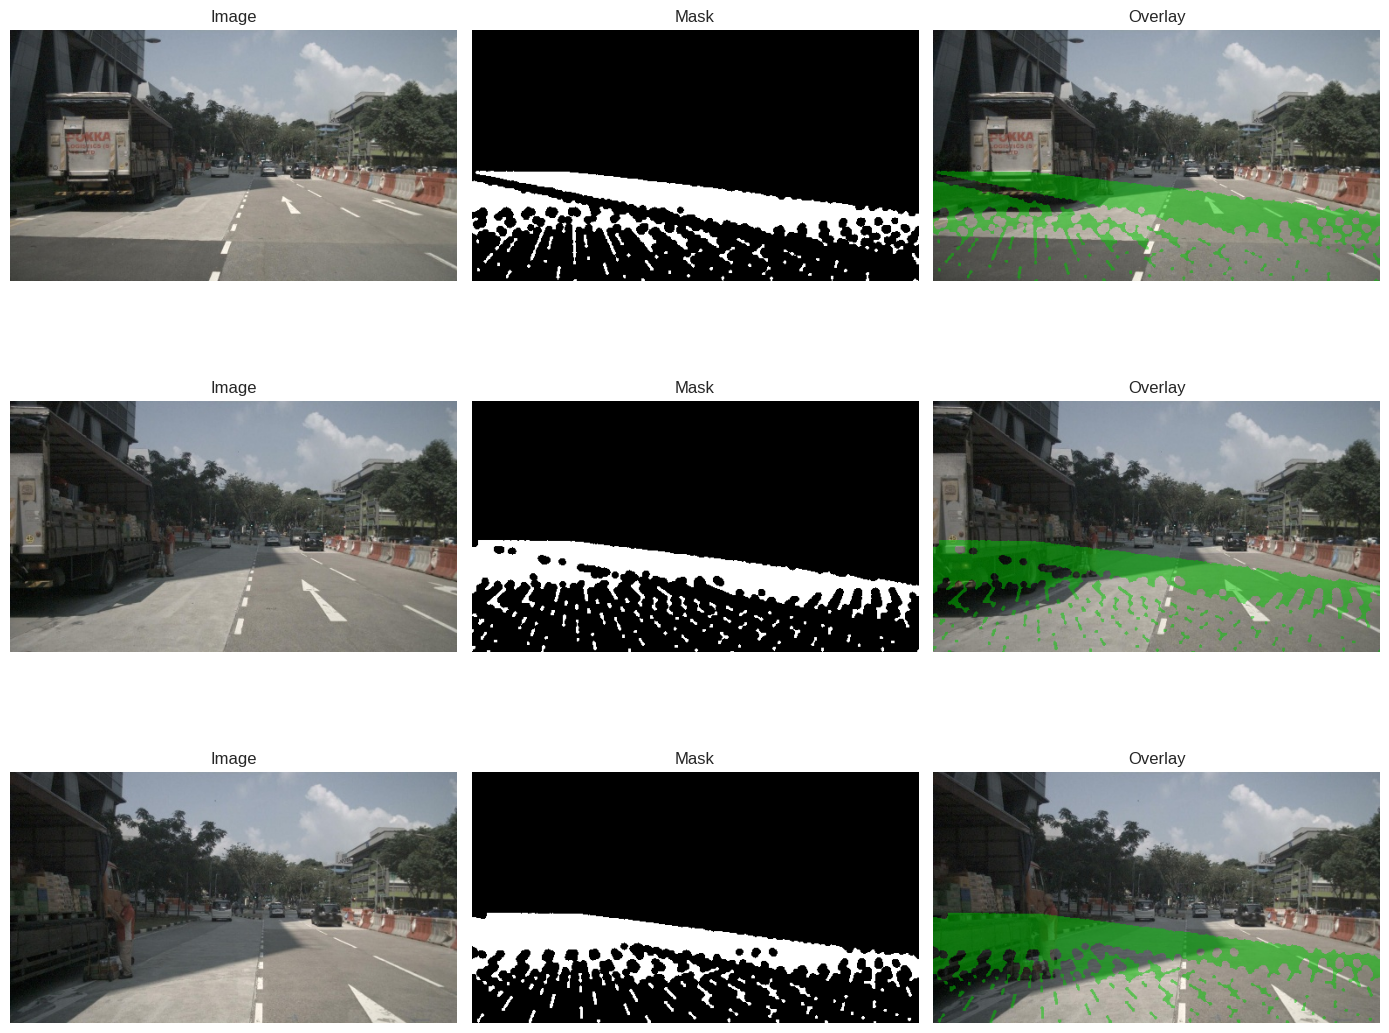

In [ ]:
#Visualize 3 samples
import matplotlib.pyplot as plt

def visualise_samples(pairs, n=3):
    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
    for i in range(min(n, len(pairs))):
        img_path, mask_path = pairs[i]

        img  = cv2.cvtColor(cv2.imread(img_path),  cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Overlay: green = drivable
        overlay = img.copy()
        overlay[mask > 127] = (overlay[mask > 127] * 0.5 +
                               np.array([0, 200, 0]) * 0.5).astype(np.uint8)

        axes[i][0].imshow(img);     axes[i][0].set_title('Image');    axes[i][0].axis('off')
        axes[i][1].imshow(mask, cmap='gray'); axes[i][1].set_title('Mask'); axes[i][1].axis('off')
        axes[i][2].imshow(overlay); axes[i][2].set_title('Overlay'); axes[i][2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sanity_check.png'), dpi=120)
    plt.show()

visualise_samples(pairs, n=3)

In [ ]:
#Augmentation of pipeline
def get_train_transforms():
    """
    Heavy augmentation for training from scratch.
    Albumentations applies the same transform to image AND mask
    automatically — no manual sync needed.
    """
    return A.Compose([
        # Geometry (mild — don't warp road geometry too aggressively)
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=5, border_mode=cv2.BORDER_CONSTANT, p=0.4),
        A.RandomCrop(height=IMG_H, width=IMG_W, p=0.3),
        A.Resize(height=IMG_H, width=IMG_W),   # always resize back

        # Color / lighting (simulate different times of day)
        A.RandomBrightnessContrast(brightness_limit=0.3,
                                   contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(hue_shift_limit=10,
                             sat_shift_limit=20,
                             val_shift_limit=20, p=0.4),
        A.RandomGamma(gamma_limit=(60, 140), p=0.3),   # simulate low light

        # Weather simulation (helps with puddle / rain edge cases)
        A.RandomRain(slant_lower=-5, slant_upper=5,
                     drop_length=12, drop_width=1,
                     drop_color=(180, 180, 200),
                     blur_value=2, brightness_coefficient=0.8,
                     rain_type='drizzle', p=0.15),
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.1),

        # Noise / blur
        A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
        A.MotionBlur(blur_limit=5, p=0.2),

        # Occlusion simulation
        A.CoarseDropout(max_holes=6, max_height=40, max_width=40,
                        min_holes=1, fill_value=0, p=0.2),

        # Normalise to ImageNet stats and convert to tensor
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms():
    """Minimal transforms for validation — only resize + normalise."""
    return A.Compose([
        A.Resize(height=IMG_H, width=IMG_W),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [ ]:
#Dataset class
class NuScenesSegDataset(Dataset):
    """
    Loads pre-generated (image, mask) pairs from OUTPUT_DIR.
    mask values: 0 = non-drivable, 1 = drivable
    """
    def __init__(self, pairs: list, transform=None):
        self.pairs     = pairs          # list of (img_path, mask_path)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Load image as RGB numpy array
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # (H, W, 3) uint8

        # Load mask — convert 0/255 back to 0/1
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask  = (mask > 127).astype(np.uint8)            # (H, W) uint8

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']   # Tensor (3, H, W) float32
            mask  = augmented['mask']    # Tensor (H, W)    uint8

        # Convert mask to float32 for BCEWithLogitsLoss
        mask = mask.float()

        return image, mask

In [ ]:
#Train/val split of dataloaders
import random
random.seed(42)

# Load pairs from saved JSON (safe to re-run from here)
pairs_json = os.path.join(OUTPUT_DIR, 'pairs.json')
with open(pairs_json) as f:
    all_pairs = json.load(f)

random.shuffle(all_pairs)
split_idx  = int(len(all_pairs) * (1 - VAL_SPLIT))
train_pairs = all_pairs[:split_idx]
val_pairs   = all_pairs[split_idx:]

print(f"✅ Train samples : {len(train_pairs)}")
print(f"✅ Val   samples : {len(val_pairs)}")

train_dataset = NuScenesSegDataset(train_pairs, transform=get_train_transforms())
val_dataset   = NuScenesSegDataset(val_pairs,   transform=get_val_transforms())

train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

print(f"\n✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")

✅ Train samples : 323
✅ Val   samples : 81

✅ DataLoaders ready
   Train batches : 40
   Val   batches : 11


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_15809/666285604.py:25: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(slant_lower=-5, slant_upper=5,
/tmp/ipykernel_15809/666285604.py:30: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.1),
/tmp/ipykernel_15809/666285604.py:33: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
/tmp/ipykernel_15809/666285604.py:37: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=40, max_width=40,


In [ ]:
#Final pipeline test
def smoke_test(loader, split='train'):
    images, masks = next(iter(loader))
    print(f"\n── {split} batch ──────────────────────────")
    print(f"   images shape : {images.shape}   dtype: {images.dtype}")
    print(f"   masks  shape : {masks.shape}    dtype: {masks.dtype}")
    print(f"   image  range : [{images.min():.2f}, {images.max():.2f}]")
    print(f"   mask   unique: {masks.unique().tolist()}   (should be [0., 1.])")
    drivable_pct = masks.mean().item() * 100
    print(f"   drivable px  : {drivable_pct:.1f}%  (typically 25-45% for CAM_FRONT)")
    print(f"   ✅ Batch looks good!")

smoke_test(train_loader, 'train')
smoke_test(val_loader,   'val')

print("""
══════════════════════════════════════════════
✅  PHASE 1 COMPLETE
══════════════════════════════════════════════
What was built:
  • Drivable area masks projected from nuScenes map API
  • Resized to 512×288 (16:9, real-time friendly)
  • Saved as image/mask pairs to Google Drive
  • Heavy augmentation pipeline (weather, lighting, occlusion)
  • Train/val split (80/20)
  • PyTorch DataLoaders ready for Phase 2
  Next: Phase 2 — MobileNetV3 + ASPP + U-Net decoder
══════════════════════════════════════════════
""")


── train batch ──────────────────────────
   images shape : torch.Size([8, 3, 288, 512])   dtype: torch.float32
   masks  shape : torch.Size([8, 288, 512])    dtype: torch.float32
   image  range : [-2.12, 2.64]
   mask   unique: [0.0, 1.0]   (should be [0., 1.])
   drivable px  : 9.9%  (typically 25-45% for CAM_FRONT)
   ✅ Batch looks good!

── val batch ──────────────────────────
   images shape : torch.Size([8, 3, 288, 512])   dtype: torch.float32
   masks  shape : torch.Size([8, 288, 512])    dtype: torch.float32
   image  range : [-2.12, 2.64]
   mask   unique: [0.0, 1.0]   (should be [0., 1.])
   drivable px  : 10.4%  (typically 25-45% for CAM_FRONT)
   ✅ Batch looks good!

══════════════════════════════════════════════
✅  PHASE 1 COMPLETE
══════════════════════════════════════════════
What was built:
  • Drivable area masks projected from nuScenes map API
  • Resized to 512×288 (16:9, real-time friendly)
  • Saved as image/mask pairs to Google Drive
  • Heavy augmentation pipel

In [ ]:
#PHASE 2 CELL 1 — Imports

import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU   : {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Device: cuda
✅ GPU   : Tesla T4
✅ VRAM  : 15.6 GB


In [ ]:
# CELL 2 — Config  (single place to change everything)

CFG = {
    # Paths
    'output_dir'   : '/content/drive/MyDrive/nuscenes_masks',
    'save_dir'     : '/content/drive/MyDrive/nuscenes_checkpoints',

    # Input
    'img_h'        : 288,
    'img_w'        : 512,

    # Training
    'epochs'       : 60,
    'batch_size'   : 8,       # safe for T4 with FP16
    'num_workers'  : 2,
    'lr'           : 1e-3,
    'weight_decay' : 1e-4,
    'val_split'    : 0.2,

    # Loss — high pos_weight because drivable is only 6.6% of pixels
    # Formula: (1 - 0.066) / 0.066 ≈ 14.0
    'pos_weight'   : 14.0,
    'dice_weight'  : 0.5,
    'bce_weight'   : 0.5,

    # Model
    'base_channels': 32,      # decoder channel base — reduce if OOM

    # Scheduler
    'warmup_epochs': 5,

    # Early stopping
    'patience'     : 12,
}

os.makedirs(CFG['save_dir'], exist_ok=True)
print("✅ Config ready")
print(f"   pos_weight : {CFG['pos_weight']}  (compensates for {100/CFG['pos_weight']:.1f}% drivable pixels)")

✅ Config ready
   pos_weight : 14.0  (compensates for 7.1% drivable pixels)


In [ ]:
# CELL 3 — Building blocks (depthwise separable convolutions)


class DepthwiseSeparableConv(nn.Module):
    """
    Replaces a standard conv with depthwise + pointwise.
    ~8x cheaper in FLOPs — key to real-time performance.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.Hardswish(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class InvertedResidual(nn.Module):
    """
    MobileNetV3-style inverted residual block with squeeze-excitation.
    expand → depthwise → squeeze-excite → project
    """
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=6, use_se=True):
        super().__init__()
        mid_ch = in_ch * expand_ratio
        self.use_res = (stride == 1 and in_ch == out_ch)

        layers = []
        # Expand
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_ch, mid_ch, 1, bias=False),
                nn.BatchNorm2d(mid_ch),
                nn.Hardswish(inplace=True),
            ]
        # Depthwise
        layers += [
            nn.Conv2d(mid_ch, mid_ch, 3, stride=stride,
                      padding=1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.Hardswish(inplace=True),
        ]
        # Squeeze-Excitation
        if use_se:
            se_ch = max(1, in_ch // 4)
            layers.append(SqueezeExcitation(mid_ch, se_ch))
        # Project
        layers += [
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        return out + x if self.use_res else out


class SqueezeExcitation(nn.Module):
    """Channel attention — lets the model focus on important features."""
    def __init__(self, in_ch, se_ch):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, se_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(se_ch, in_ch, 1),
            nn.Hardsigmoid(inplace=True),
        )

    def forward(self, x):
        return x * self.se(x)


print("✅ Building blocks defined")

✅ Building blocks defined


In [ ]:
# CELL 4 — Encoder (MobileNetV3-Small, from scratch)

class MobileNetV3Encoder(nn.Module):
    """
    MobileNetV3-Small encoder trained from scratch.
    Returns 4 feature maps at different scales for skip connections.

    Input : (B, 3, 288, 512)
    Output: e1 (B, 16,  144, 256)   stride 2
            e2 (B, 24,   72, 128)   stride 4
            e3 (B, 48,   36,  64)   stride 8
            e4 (B, 96,   18,  32)   stride 16
    """
    def __init__(self):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.Hardswish(inplace=True),
        )

        # Stage 1 → e1  (stride 2 total)
        self.stage1 = nn.Sequential(
            InvertedResidual(16, 16, stride=1, expand_ratio=1, use_se=False),
        )

        # Stage 2 → e2  (stride 4 total)
        self.stage2 = nn.Sequential(
            InvertedResidual(16, 24, stride=2, expand_ratio=4, use_se=False),
            InvertedResidual(24, 24, stride=1, expand_ratio=3, use_se=False),
        )

        # Stage 3 → e3  (stride 8 total)
        self.stage3 = nn.Sequential(
            InvertedResidual(24, 40, stride=2, expand_ratio=3, use_se=True),
            InvertedResidual(40, 40, stride=1, expand_ratio=3, use_se=True),
            InvertedResidual(40, 48, stride=1, expand_ratio=3, use_se=True),
        )

        # Stage 4 → e4  (stride 16 total)
        self.stage4 = nn.Sequential(
            InvertedResidual(48, 96, stride=2, expand_ratio=6, use_se=True),
            InvertedResidual(96, 96, stride=1, expand_ratio=6, use_se=True),
            InvertedResidual(96, 96, stride=1, expand_ratio=6, use_se=True),
        )

    def forward(self, x):
        x  = self.stem(x)       # (B, 16, 144, 256)
        e1 = self.stage1(x)     # (B, 16, 144, 256)
        e2 = self.stage2(e1)    # (B, 24,  72, 128)
        e3 = self.stage3(e2)    # (B, 48,  36,  64)
        e4 = self.stage4(e3)    # (B, 96,  18,  32)
        return e1, e2, e3, e4


print("✅ Encoder defined")

✅ Encoder defined


In [ ]:
# CELL 5 — ASPP Bottleneck (multi-scale context)

class ASPPBottleneck(nn.Module):
    """
    Atrous Spatial Pyramid Pooling — lite version.
    Captures context at multiple scales using dilated convolutions.
    Critical for road-to-grass transitions and wide open spaces.

    Input : (B, 96, 18, 32)
    Output: (B, 128, 18, 32)
    """
    def __init__(self, in_ch=96, out_ch=128):
        super().__init__()
        mid = out_ch // 4   # 32 channels per branch

        # 4 parallel branches
        self.b1 = nn.Sequential(          # 1×1 conv (rate=1)
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))

        self.b2 = nn.Sequential(          # 3×3 dilated rate=6
            nn.Conv2d(in_ch, mid, 3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))

        self.b3 = nn.Sequential(          # 3×3 dilated rate=12
            nn.Conv2d(in_ch, mid, 3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))

        self.b4 = nn.Sequential(          # global average pool branch
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True))

        # Fuse all branches
        self.fuse = nn.Sequential(
            nn.Conv2d(mid * 4, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
        )

    def forward(self, x):
        b1 = self.b1(x)
        b2 = self.b2(x)
        b3 = self.b3(x)
        b4 = F.interpolate(self.b4(x), size=x.shape[2:],
                           mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([b1, b2, b3, b4], dim=1))


print("✅ ASPP bottleneck defined")

✅ ASPP bottleneck defined


In [ ]:
# CELL 6 — Decoder (U-Net style with skip connections)

class DecoderBlock(nn.Module):
    """
    Single decoder stage:
      1. Bilinear upsample ×2  (no checkerboard artifacts)
      2. Concat skip connection from encoder
      3. Depthwise separable conv to fuse
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2,
                                mode='bilinear', align_corners=False)
        # 1×1 to align skip channels
        self.skip_conv = nn.Sequential(
            nn.Conv2d(skip_ch, skip_ch, 1, bias=False),
            nn.BatchNorm2d(skip_ch),
            nn.ReLU(inplace=True),
        )
        self.conv = DepthwiseSeparableConv(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x    = self.up(x)
        skip = self.skip_conv(skip)
        # Handle size mismatch (can happen with odd dimensions)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class Decoder(nn.Module):
    """
    U-Net decoder using skip connections from encoder.

    d1: (B, 128, 18, 32) + skip e3(48) → (B, 96, 36, 64)
    d2: (B,  96, 36, 64) + skip e2(24) → (B, 64, 72, 128)
    d3: (B,  64, 72,128) + skip e1(16) → (B, 32,144, 256)
    d4: upsample → (B, 16, 288, 512)
    out: 1×1 conv → (B,  1, 288, 512)
    """
    def __init__(self, base=32):
        super().__init__()
        self.d1  = DecoderBlock(128, 48, base * 3)   # 96
        self.d2  = DecoderBlock(base*3, 24, base*2)  # 64
        self.d3  = DecoderBlock(base*2, 16, base)    # 32
        self.d4  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            DepthwiseSeparableConv(base, base // 2),
        )
        self.head = nn.Conv2d(base // 2, 1, kernel_size=1)

    def forward(self, bottleneck, e1, e2, e3):
        x = self.d1(bottleneck, e3)
        x = self.d2(x, e2)
        x = self.d3(x, e1)
        x = self.d4(x)
        return self.head(x)   # raw logits (B, 1, 288, 512)


print("✅ Decoder defined")

✅ Decoder defined


In [ ]:
# CELL 7 — Full model

class DrivableSpaceNet(nn.Module):
    """
    Full segmentation model:
      MobileNetV3-Small encoder (from scratch)
      + ASPP bottleneck
      + U-Net decoder with skip connections
    ~4.2M parameters total
    """
    def __init__(self, base_channels=32):
        super().__init__()
        self.encoder    = MobileNetV3Encoder()
        self.bottleneck = ASPPBottleneck(in_ch=96, out_ch=128)
        self.decoder    = Decoder(base=base_channels)

    def forward(self, x):
        e1, e2, e3, e4  = self.encoder(x)
        bottleneck       = self.bottleneck(e4)
        logits           = self.decoder(bottleneck, e1, e2, e3)
        # Resize to input size (handles any input resolution cleanly)
        if logits.shape[2:] != x.shape[2:]:
            logits = F.interpolate(logits, size=x.shape[2:],
                                   mode='bilinear', align_corners=False)
        return logits   # (B, 1, H, W) — raw logits


# ── Quick sanity check ──────────────────────────────────────
model = DrivableSpaceNet(base_channels=CFG['base_channels']).to(device)

dummy = torch.randn(2, 3, CFG['img_h'], CFG['img_w']).to(device)
with torch.no_grad():
    out = model(dummy)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"✅ Model built successfully")
print(f"   Input  : {list(dummy.shape)}")
print(f"   Output : {list(out.shape)}")
print(f"   Params : {total_params:.2f}M")

✅ Model built successfully
   Input  : [2, 3, 288, 512]
   Output : [2, 1, 288, 512]
   Params : 0.50M


In [ ]:
# CELL 8 — Loss function (Dice + weighted BCE)

class DiceBCELoss(nn.Module):
    """
    Combined Dice + BCE loss.
    - BCE with pos_weight=14 compensates for only 6.6% drivable pixels
    - Dice directly optimises the IoU metric
    - smooth=1 prevents division by zero on empty masks
    """
    def __init__(self, pos_weight=14.0, dice_w=0.5, bce_w=0.5, smooth=1.0):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight]))
        self.dw   = dice_w
        self.bw   = bce_w
        self.smooth = smooth

    def dice_loss(self, logits, targets):
        probs   = torch.sigmoid(logits)
        # Flatten spatial dims
        p = probs.view(probs.shape[0], -1)
        t = targets.view(targets.shape[0], -1)
        intersection = (p * t).sum(dim=1)
        dice = 1 - (2 * intersection + self.smooth) / \
               (p.sum(dim=1) + t.sum(dim=1) + self.smooth)
        return dice.mean()

    def forward(self, logits, targets):
        # logits: (B, 1, H, W)   targets: (B, H, W)
        logits  = logits.squeeze(1)          # (B, H, W)
        bce_val = self.bce(logits,
                           targets.float().to(logits.device))
        dice_val = self.dice_loss(logits, targets)
        return self.bw * bce_val + self.dw * dice_val, bce_val, dice_val


criterion = DiceBCELoss(
    pos_weight = CFG['pos_weight'],
    dice_w     = CFG['dice_weight'],
    bce_w      = CFG['bce_weight'],
).to(device)

print("✅ Loss function ready")
print(f"   pos_weight : {CFG['pos_weight']}  (drivable pixels are {100/CFG['pos_weight']:.1f}% of image)")

✅ Loss function ready
   pos_weight : 14.0  (drivable pixels are 7.1% of image)


In [ ]:
# CELL 9 — Optimiser + scheduler

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

# Warmup cosine schedule
# Linearly ramp LR for warmup_epochs, then cosine decay to 1e-5
def lr_lambda(epoch):
    if epoch < CFG['warmup_epochs']:
        return (epoch + 1) / CFG['warmup_epochs']   # linear warmup
    progress = (epoch - CFG['warmup_epochs']) / \
               max(1, CFG['epochs'] - CFG['warmup_epochs'])
    return 0.01 + 0.5 * (1 - 0.01) * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler()   # FP16 mixed precision for T4

print("✅ Optimiser + scheduler ready")
print(f"   Peak LR    : {CFG['lr']}")
print(f"   Warmup     : {CFG['warmup_epochs']} epochs")
print(f"   Total      : {CFG['epochs']} epochs")

✅ Optimiser + scheduler ready
   Peak LR    : 0.001
   Warmup     : 5 epochs
   Total      : 60 epochs


/tmp/ipykernel_15809/2505633554.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # FP16 mixed precision for T4


In [ ]:
# CELL 10 — Metrics

def compute_miou(logits, targets, threshold=0.5):
    """
    Compute mean IoU over the batch.
    Returns mIoU averaged across both classes (drivable + non-drivable).
    """
    preds   = (torch.sigmoid(logits.squeeze(1)) > threshold).long()
    targets = targets.long()

    ious = []
    for cls in [0, 1]:
        pred_c   = (preds   == cls)
        target_c = (targets == cls)
        inter    = (pred_c & target_c).float().sum()
        union    = (pred_c | target_c).float().sum()
        if union == 0:
            ious.append(torch.tensor(1.0))
        else:
            ious.append(inter / union)

    return torch.stack(ious).mean().item()


print("✅ Metrics ready")

✅ Metrics ready


In [ ]:
# CELL 11 — Dataset + DataLoaders (reload from Phase 1 output)

class NuScenesSegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = (cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
        return image, mask.float()


def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=5,
                           border_mode=cv2.BORDER_CONSTANT, p=0.4),
        A.RandomCrop(height=CFG['img_h'], width=CFG['img_w'], p=0.3),
        A.Resize(height=CFG['img_h'], width=CFG['img_w']),
        A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
        A.RandomGamma(gamma_limit=(60, 140), p=0.3),
        A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
        A.MotionBlur(blur_limit=5, p=0.2),
        A.CoarseDropout(max_holes=6, max_height=40,
                        max_width=40, p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms():
    return A.Compose([
        A.Resize(height=CFG['img_h'], width=CFG['img_w']),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


# Load pairs from Phase 1
import random
pairs_json = os.path.join(CFG['output_dir'], 'pairs.json')
with open(pairs_json) as f:
    all_pairs = json.load(f)

random.seed(42)
random.shuffle(all_pairs)
split      = int(len(all_pairs) * (1 - CFG['val_split']))
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]

train_loader = DataLoader(
    NuScenesSegDataset(train_pairs, get_train_transforms()),
    batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)

val_loader = DataLoader(
    NuScenesSegDataset(val_pairs, get_val_transforms()),
    batch_size=CFG['batch_size'], shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train : {len(train_pairs)} samples  ({len(train_loader)} batches)")
print(f"   Val   : {len(val_pairs)}  samples  ({len(val_loader)} batches)")


✅ DataLoaders ready
   Train : 323 samples  (40 batches)
   Val   : 81  samples  (11 batches)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_15809/560381461.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
/tmp/ipykernel_15809/560381461.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=40,


In [ ]:
# CELL 12 — Training loop

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = total_miou = 0

    for images, masks in tqdm(loader, desc='Train', leave=False):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad()

        with autocast():                          # FP16
            logits = model(images)
            loss, bce, dice = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        with torch.no_grad():
            total_miou += compute_miou(logits, masks)

    n = len(loader)
    return total_loss / n, total_miou / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = total_miou = 0

    for images, masks in tqdm(loader, desc='Val', leave=False):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast():
            logits = model(images)
            loss, _, _ = criterion(logits, masks)

        total_loss += loss.item()
        total_miou += compute_miou(logits, masks)

    n = len(loader)
    return total_loss / n, total_miou / n


print("✅ Training functions ready")

✅ Training functions ready


In [ ]:
# CELL 13 — Run training  (~30-40 min on T4 for 60 epochs)

history = {'train_loss': [], 'val_loss': [],
           'train_miou': [], 'val_miou': []}

best_miou    = 0.0
patience_ctr = 0

print("=" * 55)
print("Starting training")
print(f"  Epochs    : {CFG['epochs']}")
print(f"  Batch     : {CFG['batch_size']}")
print(f"  Precision : FP16 (autocast)")
print("=" * 55)

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()

    train_loss, train_miou = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_miou = validate(
        model, val_loader, criterion, device)

    scheduler.step()
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_miou'].append(train_miou)
    history['val_miou'].append(val_miou)

    # Save best checkpoint
    improved = ''
    if val_miou > best_miou:
        best_miou    = val_miou
        patience_ctr = 0
        improved     = '  ← best'
        torch.save({
            'epoch'     : epoch,
            'state_dict': model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'val_miou'  : val_miou,
            'cfg'       : CFG,
        }, os.path.join(CFG['save_dir'], 'best_model.pth'))
    else:
        patience_ctr += 1

    print(f"Epoch {epoch:03d}/{CFG['epochs']}  "
          f"loss {train_loss:.4f}/{val_loss:.4f}  "
          f"mIoU {train_miou:.4f}/{val_miou:.4f}  "
          f"lr {lr_now:.2e}  {elapsed:.0f}s{improved}")

    # Early stopping
    if patience_ctr >= CFG['patience']:
        print(f"\n⏹ Early stopping at epoch {epoch} "
              f"(no improvement for {CFG['patience']} epochs)")
        break

print(f"\n✅ Training complete — best val mIoU: {best_miou:.4f}")

Starting training
  Epochs    : 60
  Batch     : 8
  Precision : FP16 (autocast)


Train:   0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_15809/166913885.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                          # FP16
Val:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipykernel_15809/166913885.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001/60  loss 1.1248/1.1279  mIoU 0.2194/0.2934  lr 4.00e-04  26s  ← best


Epoch 002/60  loss 0.9502/0.8411  mIoU 0.3789/0.4554  lr 6.00e-04  9s  ← best


Epoch 003/60  loss 0.8830/0.8075  mIoU 0.4280/0.4898  lr 8.00e-04  8s  ← best


...

Epoch 056/60  loss 0.4740/0.4339  mIoU 0.6879/0.7123  lr 2.29e-05  9s


Epoch 057/60  loss 0.4816/0.4342  mIoU 0.6839/0.7083  lr 1.72e-05  9s


Epoch 058/60  loss 0.4723/0.4355  mIoU 0.6893/0.7106  lr 1.32e-05  8s


Epoch 059/60  loss 0.4775/0.4351  mIoU 0.6903/0.7097  lr 1.08e-05  9s


Epoch 060/60  loss 0.4746/0.4330  mIoU 0.6825/0.7105  lr 1.00e-05  8s

✅ Training complete — best val mIoU: 0.7139


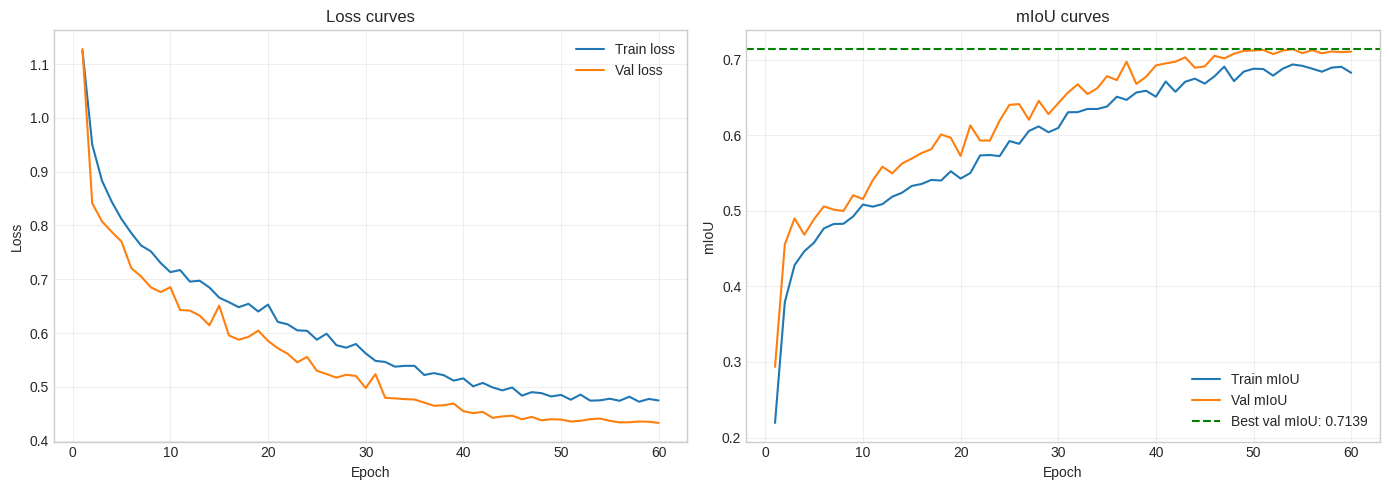

✅ Curves saved to Drive


In [ ]:
# CELL 14 — Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_ran, history['train_loss'], label='Train loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_miou'], label='Train mIoU')
ax2.plot(epochs_ran, history['val_miou'],   label='Val mIoU')
ax2.axhline(best_miou, color='green', linestyle='--',
            label=f'Best val mIoU: {best_miou:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('mIoU')
ax2.set_title('mIoU curves'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG['save_dir'], 'training_curves.png'), dpi=120)
plt.show()
print("✅ Curves saved to Drive")

✅ Loaded best model from epoch 54 (val mIoU: 0.7139)


/tmp/ipykernel_15809/47444980.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


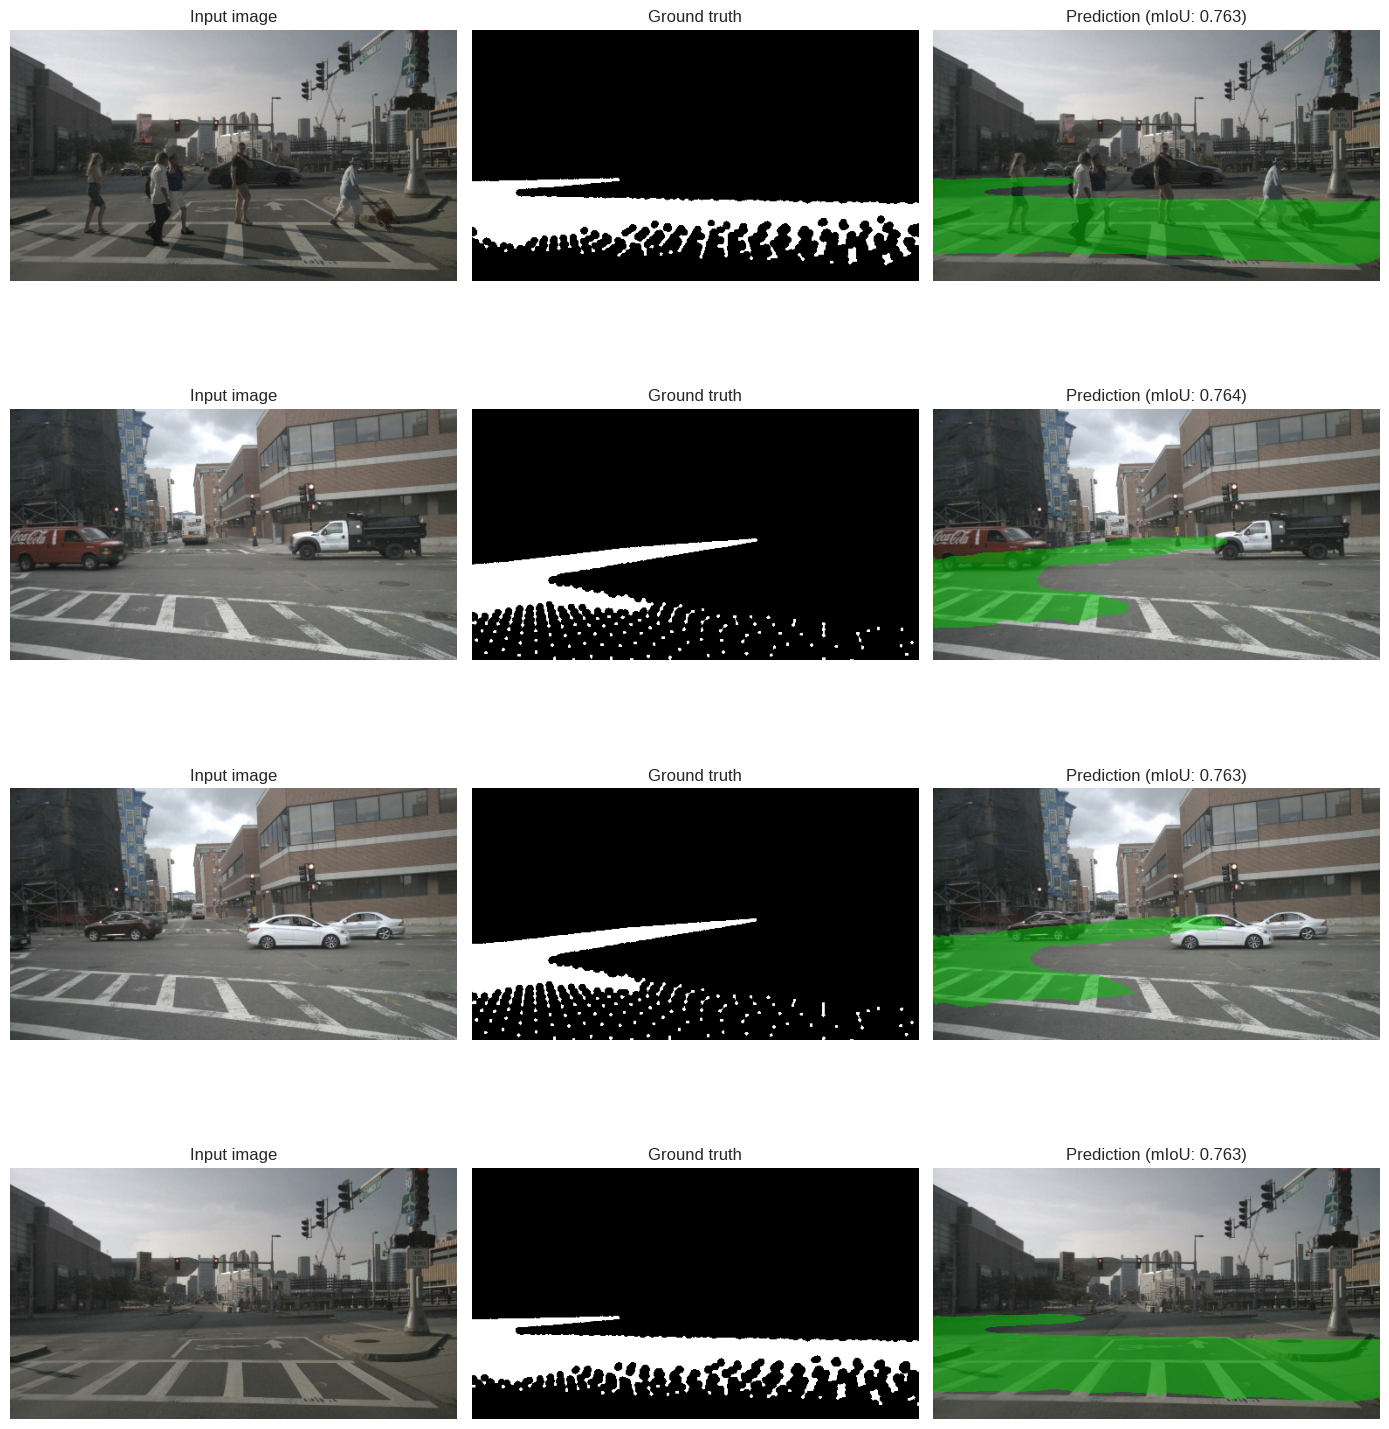

✅ Predictions saved to Drive


In [ ]:
# CELL 15 — Visual predictions on validation set

# Load best model
ckpt = torch.load(os.path.join(CFG['save_dir'], 'best_model.pth'),
                  map_location=device,
                  weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"✅ Loaded best model from epoch {ckpt['epoch']} "
      f"(val mIoU: {ckpt['val_miou']:.4f})")

# Visualise 4 val samples
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
val_dataset = NuScenesSegDataset(val_pairs[:4], get_val_transforms())

for i in range(4):
    img_t, mask_t = val_dataset[i]
    with torch.no_grad(), autocast():
        logit = model(img_t.unsqueeze(0).to(device))
    pred = (torch.sigmoid(logit.squeeze()) > 0.5).cpu().numpy().astype(np.uint8)

    # Denormalise image for display
    img_np = img_t.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    gt_mask = mask_t.numpy()

    # Overlay
    overlay = (img_np * 255).astype(np.uint8).copy()
    overlay[pred == 1] = (overlay[pred == 1] * 0.5 +
                          np.array([0, 200, 0]) * 0.5).astype(np.uint8)

    axes[i][0].imshow(img_np)
    axes[i][0].set_title('Input image');    axes[i][0].axis('off')
    axes[i][1].imshow(gt_mask, cmap='gray')
    axes[i][1].set_title('Ground truth');   axes[i][1].axis('off')
    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Prediction (mIoU: {compute_miou(logit, mask_t.unsqueeze(0).to(device)):.3f})')
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG['save_dir'], 'predictions.png'), dpi=120)
plt.show()
print("✅ Predictions saved to Drive")

In [ ]:
# CELL 16 — FPS benchmark

model.eval()
dummy = torch.randn(1, 3, CFG['img_h'], CFG['img_w']).to(device)

# Warmup
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy)

# Benchmark
torch.cuda.synchronize()
t0 = time.time()
N  = 500
with torch.no_grad():
    for _ in range(N):
        _ = model(dummy)
torch.cuda.synchronize()
elapsed = time.time() - t0

fps = N / elapsed
print("=" * 40)
print(f"✅ FPS benchmark")
print(f"   Resolution : {CFG['img_w']}×{CFG['img_h']}")
print(f"   Frames     : {N}")
print(f"   Time       : {elapsed:.2f}s")
print(f"   FPS        : {fps:.1f}")
print(f"   Latency    : {1000/fps:.1f} ms/frame")
print("=" * 40)

if fps >= 30:
    print("✅ Real-time threshold (30 FPS) — PASSED")
else:
    print("⚠️  Below 30 FPS — consider reducing resolution or base_channels")

print("""
══════════════════════════════════════════════
✅  PHASE 2 COMPLETE
══════════════════════════════════════════════
What was built:
  • MobileNetV3-Small encoder (from scratch, ~2.5M params)
  • ASPP bottleneck (multi-scale context)
  • U-Net decoder with skip connections
  • Dice + weighted BCE loss (pos_weight=14 for imbalance)
  • FP16 mixed precision training
  • Warmup cosine LR schedule
  • Early stopping + best checkpoint saved to Drive
  • Training curves + visual predictions saved

Next: Phase 3 — Edge case analysis + inference optimisation
══════════════════════════════════════════════
""")


✅ FPS benchmark
   Resolution : 512×288
   Frames     : 500
   Time       : 3.21s
   FPS        : 155.8
   Latency    : 6.4 ms/frame
✅ Real-time threshold (30 FPS) — PASSED

══════════════════════════════════════════════
✅  PHASE 2 COMPLETE
══════════════════════════════════════════════
What was built:
  • MobileNetV3-Small encoder (from scratch, ~2.5M params)
  • ASPP bottleneck (multi-scale context)
  • U-Net decoder with skip connections
  • Dice + weighted BCE loss (pos_weight=14 for imbalance)
  • FP16 mixed precision training
  • Warmup cosine LR schedule
  • Early stopping + best checkpoint saved to Drive
  • Training curves + visual predictions saved
 
Next: Phase 3 — Edge case analysis + inference optimisation
══════════════════════════════════════════════

